In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [3]:
df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [7]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(1)

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df.duplicated().sum()

np.int64(0)

In [12]:
num_col = df.select_dtypes("number").columns
num_col

Index(['age', 'bmi', 'children', 'charges'], dtype='str')

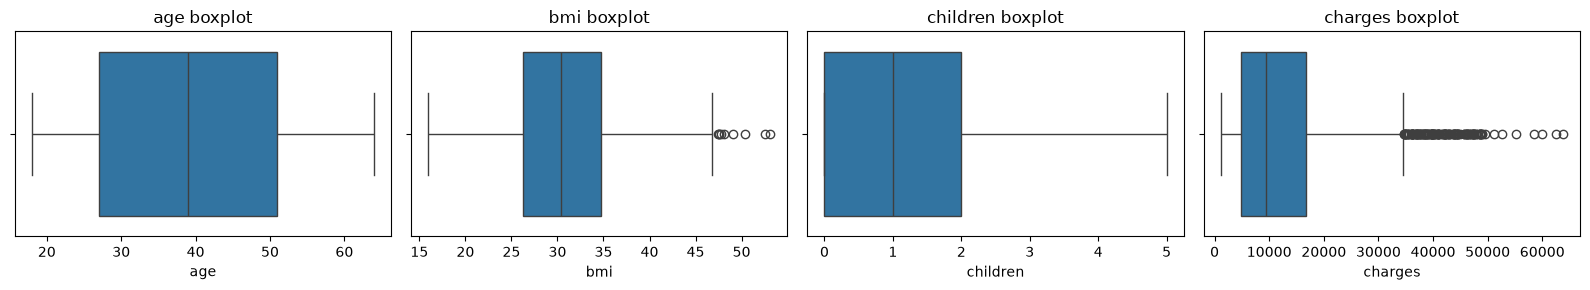

In [15]:
plt.figure(figsize=(4 * len(num_col), 3))

for i, col in enumerate(num_col):
    plt.subplot(1, len(num_col), i + 1)
    sns.boxplot(x=df[col])
    plt.title(f"{col} boxplot")

plt.tight_layout()
plt.show()

In [16]:
for col in num_col:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_fence = Q1 - 1.5 * IQR
    upper_fence = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower_fence, upper_fence)


In [17]:
df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.650247,1.095737,12491.159952
std,14.044333,6.059655,1.205571,10165.511950
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,47.315000,5.000000,34524.777625


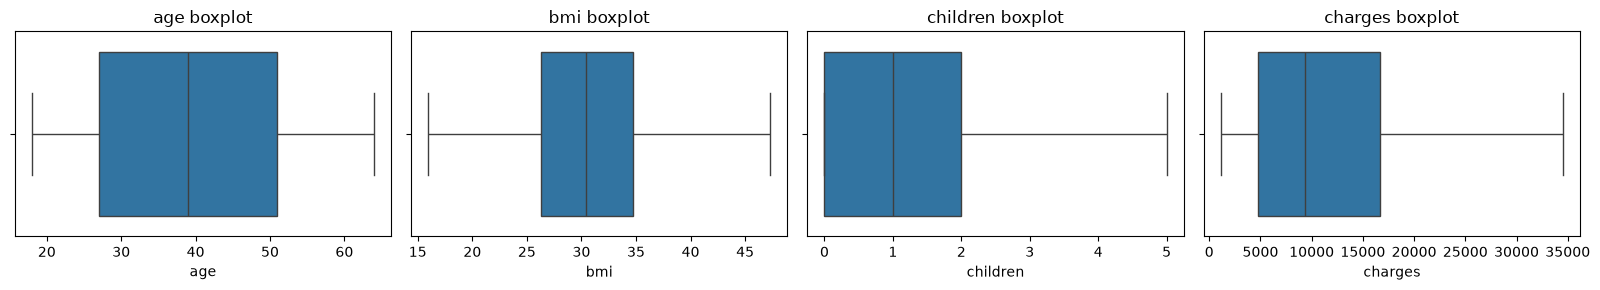

In [24]:
plt.figure(figsize=(4 * len(num_col), 3))

for i, col in enumerate(num_col):
    plt.subplot(1, 4, i + 1)
    sns.boxplot(x=df[col])
    plt.title(f"{col} boxplot")

plt.tight_layout()
plt.show()

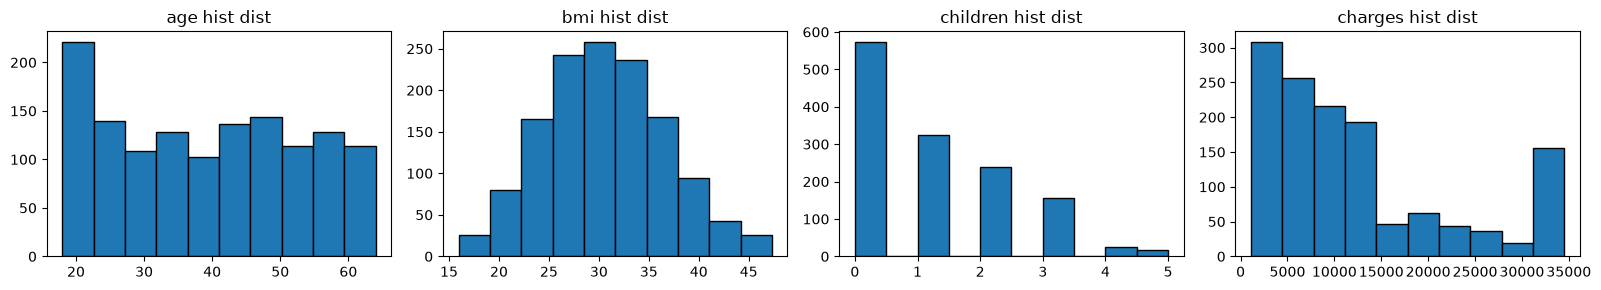

In [23]:
plt.figure(figsize=(4 * len(num_col), 3))

for i, col in enumerate(num_col):
    plt.subplot(1, 4, i + 1)
    plt.hist(df[col], edgecolor="black")
    plt.title(f"{col} hist dist")

plt.tight_layout()
plt.show()

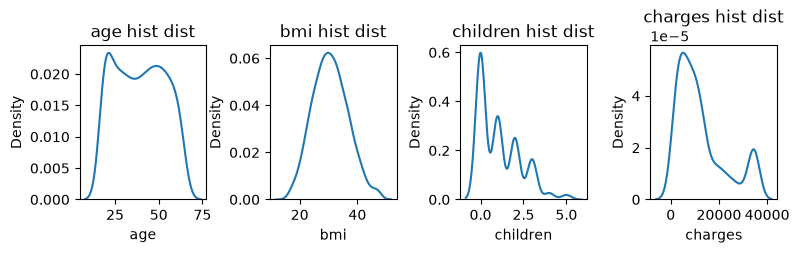

In [31]:
plt.figure(figsize=(9,2))
for i, col in enumerate(num_col):
    plt.subplot(1, 4, i+1)
    sns.kdeplot(df[col])
    plt.title(f"{col} hist dist")
plt.subplots_adjust(hspace=0.8, wspace=0.5)
plt.show()

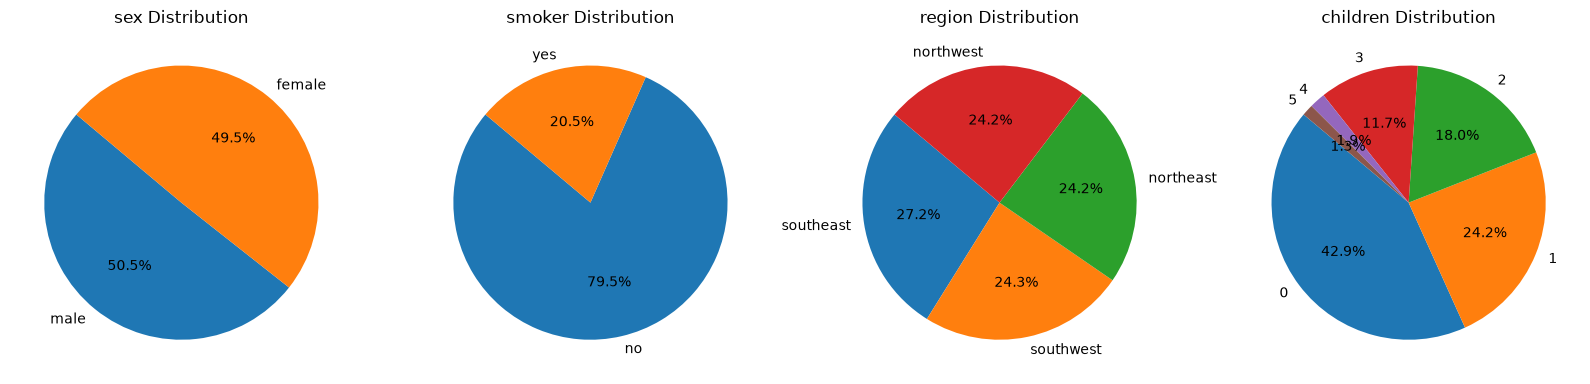

In [42]:
cat_cols = ['sex', 'smoker', 'region', 'children']

plt.figure(figsize=(16, 4))
for i, col in enumerate(cat_cols):
    plt.subplot(1, len(cat_cols), i + 1)
    unique = df[col].value_counts()
    plt.pie(unique.values, labels=unique.index, autopct='%1.1f%%', startangle=140)
    plt.title(f"{col} Distribution")

plt.tight_layout()
plt.show()

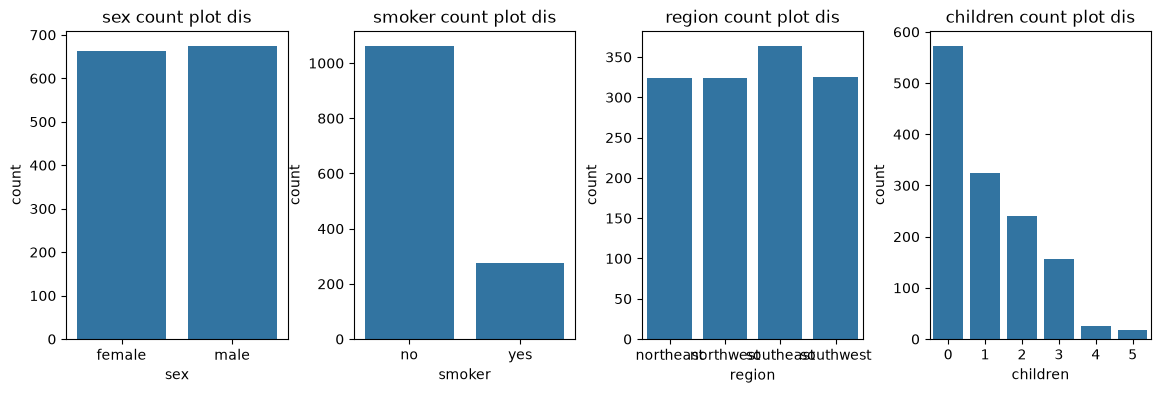

In [44]:
plt.figure(figsize=(14,4))
for i, col in enumerate(cat_cols):
    plt.subplot(1,4, i+1)
    sns.countplot(x = col, data=df)
    plt.title(f"{col} count plot dis")
plt.subplots_adjust(hspace=0.8, wspace=0.3)
plt.show()

In [45]:
unique = df["children"].value_counts()
count = unique.values
categories = unique.index

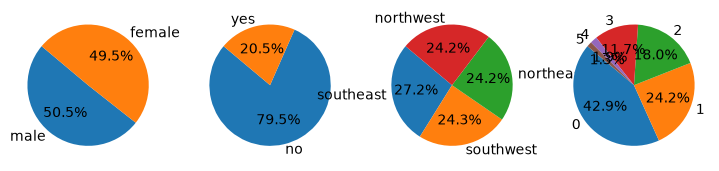

In [46]:
plt.figure(figsize=(9,4))
for i, col in enumerate(cat_cols):
    plt.subplot(1,4,i+1)
    unique = df[col].value_counts()
    count = unique.values
    categories = unique.index
    plt.pie(count, labels=categories, startangle=140, autopct='%1.1f%%')

In [47]:
fig = px.pie(df, names="children", color_discrete_sequence= px.colors.qualitative.Pastel, hole = 0.7)
fig.show()

In [50]:
fig = px.scatter(df, x="bmi", y="charges", color="smoker", title="BMI vs Charges")
fig.show()

In [53]:
##  يوسف حسين 